In [1]:
import numpy as np

# 1] 2D lattice of spin-s

In [350]:
import numpy as np
from quspin.basis import spin_basis_1d, spin_basis_general
from quspin.operators import hamiltonian

Lx, Ly = 4, 4  # linear dimension of spin 1/2 2d lattice
U, mu = 4, 1
S,Sstr = 1, "1"
sbase = int(2*S+1)

N_2d = Lx * Ly  # number of sites for spin 1/2
s = np.arange(N_2d)  # sites [0,1,2,....]
x = s % Lx  # x positions for sites
y = s // Lx  # y positions for sites
T_x = (x + 1) % Lx + Lx * y  # translation along x-direction
T_y = x + Lx * ((y + 1) % Ly)  # translation along y-direction
# P_x = x + Lx * (Ly - y - 1)  # reflection about x-axis
# P_y = (Lx - x - 1) + Lx * y  # reflection about y-axis
TT_x = (x + 2) % Lx + Lx * y  # translation along x-direction
TT_y = x + Lx * ((y + 2) % Ly)  # translation along y-direction
# Z = -(s + 1)  # spin inversion
print(T_x)
print(T_y)

[ 1  2  3  0  5  6  7  4  9 10 11  8 13 14 15 12]
[ 4  5  6  7  8  9 10 11 12 13 14 15  0  1  2  3]


In [355]:
###### setting up bases ######

basis_2d = spin_basis_general(
    N_2d,
    # kxblock=(TT_x, 0),
    # kyblock=(TT_y, 0),
    S=Sstr
)  # 2d - basis
basis_2d_0_0 = spin_basis_general(
    N_2d,
    kxblock=(TT_x, 1),
    kyblock=(TT_y, 1),
    S=Sstr
)  # 2d - basis

print("Size of 2D H-space: {Ns:d}".format(Ns=basis_2d.Ns))
print("Size of 2D H-space: {Ns:d}".format(Ns=basis_2d_0_0.Ns))

Size of 2D H-space: 43046721
Size of 2D H-space: 10760040


In [ ]:
print(basis_2d.states[0:10])
print(basis_2d_0_0.states[0:10])

psi_s = np.zeros(basis_2d.Ns)
array_ind_s = basis_2d.index(43046719)
psi_s[array_ind_s] = 1.0  # create the state |01> in the full basis
#
psi_symm_s = basis_2d_0_0.project_to(
    psi_s, sparse=False
)
print(psi_symm_s)

[43046720 43046719 43046718 43046717 43046716 43046715 43046714 43046713
 43046712 43046711]
[43046719 43046718 43046717 43046716 43046715 43046714 43046713 43046712
 43046709 43046708]


In [ ]:

s0 = basis_2d.int_to_state(basis_2d.Ns - basis_2d.states[0]-1)
print(s0)
# for state in basis_2d.states[0:10]:
#     print(state)
#     print(basis_2d.representative(state))

In [ ]:

# setting up hamiltonians

# 2d (nx)
hI_2d = [[S*mu, i] for i in range(N_2d)]
hz_2d = [[  mu, i] for i in range(N_2d)]
Hz_2d  = hamiltonian([["I", hI_2d]], [], basis=basis_2d, dtype=np.float64)
Hz_2d -= hamiltonian([["z", hz_2d]], [], basis=basis_2d, dtype=np.float64)

# 2d (nx ny)
JII_2d = [[S**2 * U, i, T_x[i]] for i in range(N_2d)] + [[S**2 * U, i, T_y[i]] for i in range(N_2d)]
JIz_2d = [[S * U, i, T_x[i]] for i in range(N_2d)] + [[S * U, i, T_y[i]] for i in range(N_2d)]
Jzz_2d = [[U, i, T_x[i]] for i in range(N_2d)] + [[U, i, T_y[i]] for i in range(N_2d)]
Hzz_2d  = hamiltonian([["II", JII_2d]], [], basis=basis_2d, dtype=np.float64)
Hzz_2d -= hamiltonian([["zI", JIz_2d], ["Iz", JIz_2d]], [], basis=basis_2d, dtype=np.float64)
Hzz_2d += hamiltonian([["zz", Jzz_2d]], [], basis=basis_2d, dtype=np.float64)

Htot = Hz_2d + Hzz_2d

In [326]:
# print(Htot.diagonal())
# index = 0
# for index in range(0, 2184):
#     print(basis_2d.int_to_state(index, bracket_notation=False))
# print(type(basis_2d.int_to_state(index, bracket_notation=False)))
# print(basis_2d[index])

# basis_2d.blocks
# print("LEN: ", len(basis_2d.states))
# for state in basis_2d.states[:10]:
#     print(state)
#     print(basis_2d.int_to_state(len(basis_2d.states) - state - 1))


# 2] Compute expectation values of occupation number

In [327]:
from quspin.operators import exp_op
import scipy
# construct gibbs state

dtype_real = np.float64
list_T_over_mu = np.logspace(-1, 4, num=9)
# list_T_over_mu = [10]

all_avg_particle_number = []
for T_over_mu in list_T_over_mu:
    exp_Htot_diag = np.exp(- Htot.diagonal()/(T_over_mu * mu))
    traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()
    # print(traceless_exp_Htot_diag)
    all_particle_number = np.zeros((len(traceless_exp_Htot_diag), N_2d))
    for index, proba in enumerate(traceless_exp_Htot_diag):
        str_state = basis_2d.int_to_state(sbase**N_2d - basis_2d.states[index]-2, bracket_notation=False)
        # print(str_state, proba)
        all_particle_number[index, :] = np.array(list(map(int,str_state))) * proba

    avg_particle_number = np.sum(all_particle_number, axis=0)
    all_avg_particle_number.append(avg_particle_number)

print(np.round(all_avg_particle_number, decimals=1))

[[0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.2 0.  0.2 0.4]
 [0.  0.  0.2 0.1 0.2 0.7 0.2 0.9 1.5]
 [0.  0.  0.5 0.3 0.5 0.8 0.5 0.9 1.4]
 [0.  0.2 1.  0.7 0.9 1.  0.9 0.9 1. ]
 [0.  0.4 1.2 1.  1.1 1.2 1.1 1.  0.9]
 [0.  0.5 1.3 1.  1.2 1.2 1.2 1.1 0.9]
 [0.  0.5 1.3 1.  1.2 1.2 1.2 1.1 0.8]
 [0.  0.5 1.3 1.1 1.2 1.3 1.2 1.1 0.8]]


In [328]:
# for index, proba in enumerate(traceless_exp_Htot_diag):
    # str_state = basis_2d.int_to_state(sbase**N_2d - basis_2d.states[index]-2, bracket_notation=False)
    # print(str_state, basis_2d.states[index])

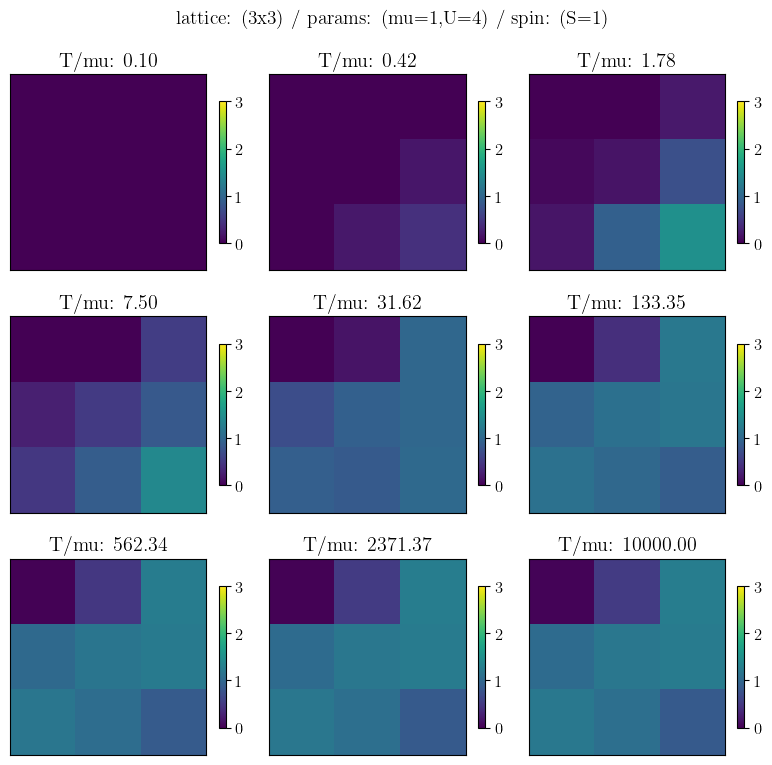

In [329]:
import matplotlib.pyplot as plt
# print(all_avg_particle_number)

ncols = 3
fig, ax = plt.subplots(ncols = ncols, nrows=len(list_T_over_mu)//ncols, figsize = (8, 8))
for ii, T_over_mu, avg_particle_number in zip(range(len(list_T_over_mu)), list_T_over_mu, all_avg_particle_number):
    img = ax[ii//ncols][ii%ncols].imshow(np.round(avg_particle_number, decimals=2).reshape((Lx, Ly)), vmin=0, vmax = sbase)
    ax[ii//ncols][ii%ncols].set_title(f"T/mu: {T_over_mu:.02f}")
    ax[ii//ncols][ii%ncols].set_xticks([])
    ax[ii//ncols][ii%ncols].set_yticks([])
    fig.colorbar(img, ax=ax[ii//ncols][ii%ncols], shrink=0.6)
# plt.plot(list_beta, all_avg_particle_number)

plt.suptitle(f"lattice: ({Lx}x{Ly}) / params: (mu={mu},U={U}) / spin: (S={Sstr})", fontsize=14)
fig.tight_layout()
plt.savefig(f"lattice{Lx}x{Ly}_spin_{S}.pdf")